## Chessboard class

### Notação Usada

K – King (Rei)

Q – Queen (Rainha/Dama)

R – Rook (Torre)

B – Bishop (Bispo)

N – Knight (Cavalo - usa-se N para não confundir com o Rei)

Sem letra – Pawn (Peão)


x – Captura (ex: Bxe5 ou Nxf3)

+ – Xeque

#– Xeque-mate

O-O – Roque curto (ala do rei)

O-O-O – Roque longo (ala da dama)

Exemplos: e4- peão avança para a casa a e4,  Qxf6 - Dama captura peça adversária na casa f6

In [1]:
# Biblioteca necessaria
!pip install chess

In [2]:
import chess
import chess.svg
from IPython.display import SVG, display


class ChessBoard:
    """Wraps python-chess and renders itself as SVG in Jupyter."""

    def __init__(self, fen: str = None, size: int = 400):
        self.board = chess.Board(fen) if fen else chess.Board()
        self.size = size

    def push(self, move: str):
        """Play a move in SAN ('e4', 'Nf3') or UCI ('e2e4') notation."""
        try:
            self.board.push_san(move)
        except ValueError:
            self.board.push_uci(move)
        return self

    def pop(self):
        self.board.pop()
        return self

    def reset(self):
        self.board.reset()
        return self

    def legal_moves(self) -> list[str]:
        return [self.board.san(m) for m in self.board.legal_moves]

    def is_game_over(self) -> bool:
        return self.board.is_game_over()

    def result(self) -> str:
        return self.board.result()

    def _svg(self) -> str:
        last_move = self.board.peek() if self.board.move_stack else None
        check_square = self.board.king(self.board.turn) if self.board.is_check() else None
        return chess.svg.board(
            self.board,
            size=self.size,
            lastmove=last_move,
            check=check_square,
        )

    def show(self):
        display(SVG(self._svg()))

    def _repr_svg_(self):
        # lets Jupyter auto-render the board when it's the last line in a cell
        return self._svg()

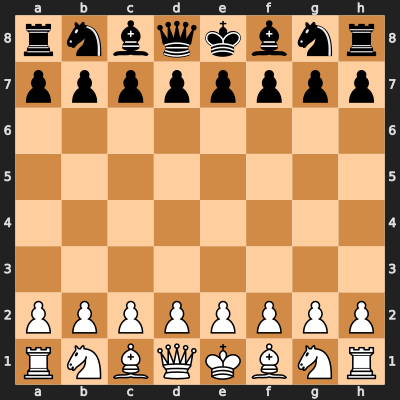

In [3]:
board = ChessBoard()
board.show()

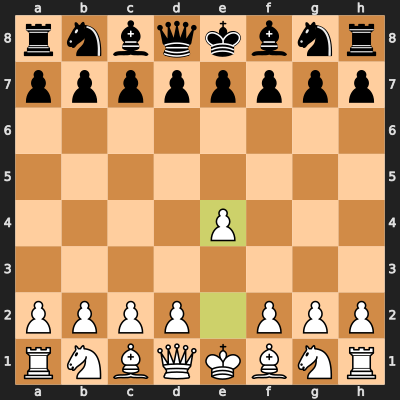

In [4]:
b=board
b.push('e4')

In [5]:
#Print the board to the console
#print(board.board)
txt_board=f'{board.board}'
print(txt_board)


r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R


In [6]:
# FEN format
pos2=board.board.fen()
pos2

'rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1'

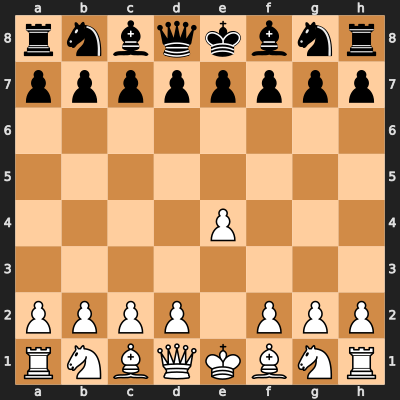

In [7]:
board2=ChessBoard(pos2)
board2.show()

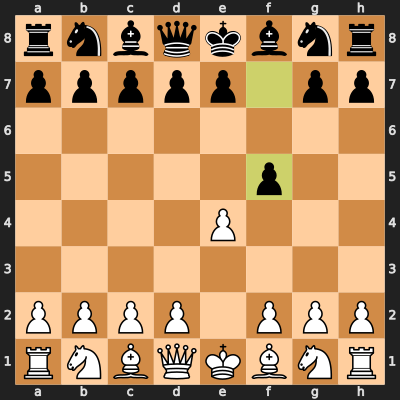

In [8]:
b.push('f5')


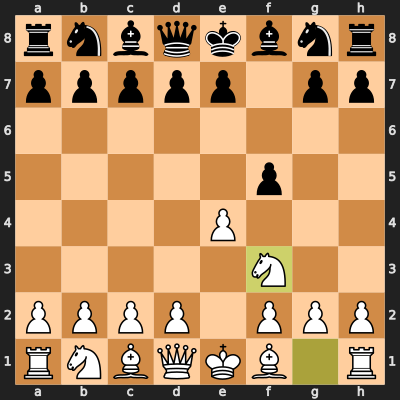

In [9]:
b.push('Nf3')


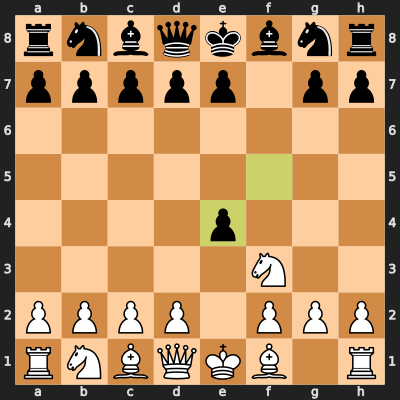

In [10]:
b.push('f5xe4')


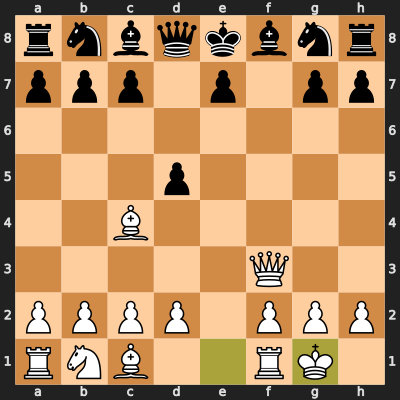

In [11]:

b.push('Bc4')
b.push('e4xf3')
b.push('Qxf3')
b.push('d5')
b.push('O-O')


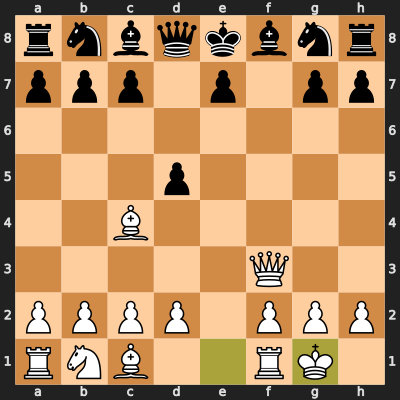

In [12]:
board

In [13]:
# Possíveis movimentos
print('Numero de possíveis movimentos',len(board.legal_moves()))
print('Lista de possiveis movimentos:')
for i,m in enumerate(board.legal_moves()): 
    print(m,end=',')
    if (i+1)%5 ==0: print()

Numero de possíveis movimentos 27
Lista de possiveis movimentos:
Nh6,Nf6,Kd7,Qd7,Qd6,
Bd7,Be6,Bf5,Bg4,Bh3,
Nd7,Nc6,Na6,dxc4,h6,
g6,e6,c6,b6,a6,
d4,h5,g5,e5,c5,
b5,a5,

In [14]:
filhos=board.legal_moves()
type(filhos)

list

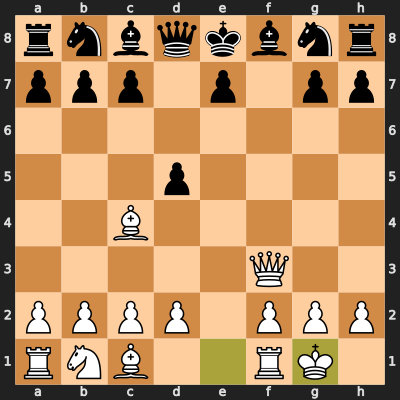

In [15]:
board

### Search Tree - Generic data

In [16]:
class TreeNode:
    def __init__(self, value, parent=None):
        self.value = value
        self.parent = parent
        self.children = []
        self.h_value=0

        if parent is not None:
            parent.children.append(self)

    def add_child(self, value):
        return TreeNode(value, parent=self)

    def __repr__(self):
        return f"TreeNode({self.value!r})"

    def set_h_value(self,v):
        # TODO 
        self.h_value=v

    def get_h_value(self):
        return self.h_value
    
def path_from_root(node: TreeNode) -> list:
    """Returns the list of values from the given node up to the root, inclusive."""
    path = []
    current = node
    while current is not None:
        path.append(current.value+' ('+str(current.get_h_value())+')')
        current = current.parent
    return path[::-1]# from root to node

    
def dfs(node: TreeNode) -> list:
    """Depth-first traversal (pre-order), returns a list of values."""
    result = [node.value]
    for child in node.children:
        result.extend(dfs(child))
    return result

def print_tree(node: TreeNode, depth: int = 0):# print in DFS
    print("&" * depth + str(node.value)+ '->'+str(node.get_h_value()))
    for child in node.children:
        print_tree(child, depth + 1)


def best_move(no, turno): # returns the best move
    
    while len(no.children) > 0:
        best_child = no.children[0]
        
        for child in no.children:
            best_value = child.get_h_value()
            best_temp = best_child.get_h_value()
            if turno == chess.WHITE:
                if best_value > best_temp:
                    best_child = child
            else:
                if best_value < best_temp:
                    best_child = child

        no = best_child
        turno = not turno

    aux = path_from_root(no)
    aux[0] = 'root'
    return aux


In [17]:
root = TreeNode("A")
b = root.add_child("B")
c = root.add_child("C")
d = b.add_child("D")
e = d.add_child("E")

print(path_from_root(e))   # ['A', 'B', 'D', 'E']
print(path_from_root(c))   # ['A', 'C']
print(path_from_root(root))  # ['A']



['A (0)', 'B (0)', 'D (0)', 'E (0)']
['A (0)', 'C (0)']
['A (0)']


In [18]:
print_tree(root)

A->0
&B->0
&&D->0
&&&E->0
&C->0


## Search Tree - Chess Boards

In [19]:
chess_game=ChessBoard()
fen=chess_game.board.fen()
chess_tree=TreeNode(fen)

In [20]:
# Create current position

chess_game.push('e4')# white
chess_game.push('f5')#black
chess_game.push('Nf3')#white
chess_game.push('f5xe4')#black
chess_game.push('Bc4')#white
chess_game.push('e4xf3')#black
chess_game.push('Qxf3')#white
chess_game.push('d5')#black


fen=chess_game.board.fen()

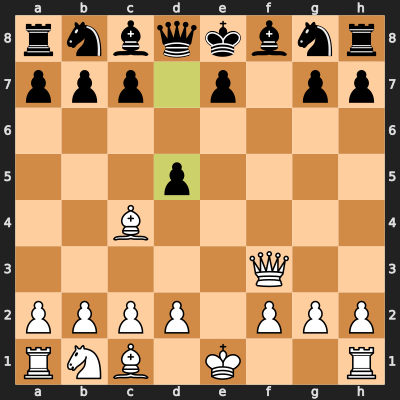

In [21]:
chess_game# visualizacao

### Funções Heurísticas dependentes do Domínio (Xadrez)

In [ ]:
#### Calculo Heuristico do valor da situação atual do tabuleiro

import chess

# Material values in centipawns (1 pawn = 100), from Michniewski's
# Simplified Evaluation Function. Bishop (330) is worth slightly more
# than knight (320) to reward keeping the bishop pair. The king is 0:
# both sides always have exactly one, so any value would cancel out.
PIECE_VALUES = {
    chess.PAWN: 100,
    chess.KNIGHT: 320,
    chess.BISHOP: 330,
    chess.ROOK: 500,
    chess.QUEEN: 900,
    chess.KING: 0,
}

# Piece-square tables: a positional bonus that depends on WHICH square
# a piece stands on. They replace the old center_control and also cover
# "development", since pieces on their starting squares score badly
# (a knight is -40 on g1 but +10 on f3).
# The tables are written from White's point of view with rank 8 first,
# while chess.A1 == 0, so White indexes with square_mirror(square) and
# Black indexes with square directly (the two mirrorings cancel out).
POSITION_VALUE = {
    chess.PAWN :  [
    0,  0,  0,  0,  0,  0,  0,  0,
    50, 50, 50, 50, 50, 50, 50, 50,
    10, 10, 20, 30, 30, 20, 10, 10,
    5,  5, 10, 25, 25, 10,  5,  5,
    0,  0,  0, 20, 20,  0,  0,  0,
    5, -5,-10,  0,  0,-10, -5,  5,
    5, 10, 10,-20,-20, 10, 10,  5,
    0,  0,  0,  0,  0,  0,  0,  0,
    ],

    chess.KNIGHT : [
    -50,-40,-30,-30,-30,-30,-40,-50,
    -40,-20,  0,  0,  0,  0,-20,-40,
    -30,  0, 10, 15, 15, 10,  0,-30,
    -30,  5, 15, 20, 20, 15,  5,-30,
    -30,  0, 15, 20, 20, 15,  0,-30,
    -30,  5, 10, 15, 15, 10,  5,-30,
    -40,-20,  0,  5,  5,  0,-20,-40,
    -50,-40,-30,-30,-30,-30,-40,-50,
    ],

    chess.BISHOP : [
    -20, -10, -10, -10, -10, -10, -10, -20,
    -10,   0,   0,   0,   0,   0,   0, -10,
    -10,   0,   5,  10,  10,   5,   0, -10,
    -10,   5,   5,  10,  10,   5,   5, -10,
    -10,   0,  10,  10,  10,  10,   0, -10,
    -10,  10,  10,  10,  10,  10,  10, -10,
    -10,   5,   0,   0,   0,   0,   5, -10,
    -20, -10, -10, -10, -10, -10, -10, -20,
    ],

    chess.ROOK : [
    0,   0,   0,   0,   0,   0,   0,   0,
    5,  10,  10,  10,  10,  10,  10,   5,
    -5,   0,   0,   0,   0,   0,   0,  -5,
    -5,   0,   0,   0,   0,   0,   0,  -5,
    -5,   0,   0,   0,   0,   0,   0,  -5,
    -5,   0,   0,   0,   0,   0,   0,  -5,
    -5,   0,   0,   0,   0,   0,   0,  -5,
    0,   0,   0,   5,   5,   0,   0,   0
    ],

    chess.QUEEN : [
    -20,-10,-10, -5, -5,-10,-10,-20,
    -10,  0,  0,  0,  0,  0,  0,-10,
    -10,  0,  5,  5,  5,  5,  0,-10,
     -5,  0,  5,  5,  5,  5,  0, -5,
      0,  0,  5,  5,  5,  5,  0, -5,
    -10,  5,  5,  5,  5,  5,  0,-10,
    -10,  0,  5,  0,  0,  0,  0,-10,
    -20,-10,-10, -5, -5,-10,-10,-20,
    ],

    chess.KING : [
    -30,-40,-40,-50,-50,-40,-40,-30,
    -30,-40,-40,-50,-50,-40,-40,-30,
    -30,-40,-40,-50,-50,-40,-40,-30,
    -30,-40,-40,-50,-50,-40,-40,-30,
    -20,-30,-30,-40,-40,-30,-30,-20,
    -10,-20,-20,-20,-20,-20,-20,-10,
     20, 20,  0,  0,  0,  0, 20, 20,
     20, 30, 10,  0,  0, 10, 30, 20,
    ],
}

# 5 cp per extra legal move. Shannon (1950) proposes 0.1 pawn = 10 cp,
# but measuring 1500 real positions showed that weight would push the
# term past a whole pawn in 10% of them, so we adopted half of it.
MOBILITY_WEIGHT = 5
# 50 cp per pawn defect (doubled or isolated), the -0.5 pawn of Shannon.
DEFECT_WEIGHT = 50
# A hanging piece costs 10% of its value, not 100%: the search will see
# the actual capture. This only flags the risk when it lies beyond the
# search horizon.
HANGING_FRACTION = 0.1


CENTER_SQUARES = [chess.D4, chess.D5, chess.E4, chess.E5]

# Sums the piece-square table value of every piece: White minus Black.
def piece_square_score(board: chess.Board) -> int:
    score = 0
    for type, value in POSITION_VALUE.items():
        for square in board.board.pieces(type, chess.WHITE) :
            score += value[chess.square_mirror(square)]
        for square in board.board.pieces(type, chess.BLACK) :
            score -= value[square]
    return score


def center_control(board: chess.Board) -> float:
    score = 0.0
    for square in CENTER_SQUARES:
        piece = board.piece_at(square)
        if piece:
            score += 30 if piece.color == chess.WHITE else -30
        score += 10 * len(board.attackers(chess.WHITE, square))
        score -= 10 * len(board.attackers(chess.BLACK, square))
    return score


def king_safety(board: chess.Board, color: bool) -> float:
    king_square = board.board.king(color)
    if king_square is None:
        return 0.0

    safety = 0.0
    rank = chess.square_rank(king_square)
    file = chess.square_file(king_square)

    # penalty for each missing pawn in the king's shield
    direction = 1 if color == chess.WHITE else -1
    shield_rank = rank + direction
    if 0 <= shield_rank <= 7:
        for f in (file - 1, file, file + 1):
            if 0 <= f <= 7:
                piece = board.board.piece_at(chess.square(f, shield_rank))
                if not (piece and piece.piece_type == chess.PAWN and piece.color == color):
                    safety -= 15

    # penalty if currently in check
    if board.board.is_check() and board.board.turn == color:
        safety -= 50

    return safety

# Counts how many pawns of one colour stand on each file
# (index 0 = file a). Both doubled and isolated pawns are derived
# from this single count.
def pawn_structure(board:ChessBoard, color: bool):
    structure = [0, 0, 0, 0, 0, 0, 0, 0]

    for square in board.board.pieces(chess.PAWN, color):
        structure[chess.square_file(square)] += 1
    return structure

# n pawns on the same file count as (n-1) defects: the first one is
# normal, every extra pawn is the problem.
def double_pawn(structure):
    double = 0
    for pawn in structure:
        if pawn > 1 : double += pawn - 1
    return double

# A pawn is isolated when no friendly pawn stands on either adjacent
# file. Files a and h have only one neighbour, so the missing side is
# treated as empty -- structure[n-1] would silently wrap around to
# file h in Python.
def isolate_pawn(structure):
    isolate = 0
    for n in range(8):
        left = structure[n-1] if n > 0 else 0
        right = structure[n+1] if n < 7 else 0
        if (structure[n] > 0) and (left == 0) and (right == 0) : 
            isolate += structure[n]
    return isolate
            



import copy

# Mobility: number of legal moves for White minus the same for Black.
# legal_moves only lists the side to move, so we flip turn on a COPY of
# the board -- changing it on the real board would corrupt the game.
def counting_moves(board:ChessBoard):
    temp = board.board.copy()
    temp.turn = chess.WHITE
    white = temp.legal_moves.count()
    temp.turn = chess.BLACK
    black = temp.legal_moves.count()
    quant = white - black
    return MOBILITY_WEIGHT * quant

# A piece is "hanging" when it is attacked and has no defender.
# attackers(not color, square) are the enemies of that piece and
# attackers(color, square) are its defenders. The king is skipped:
# an attacked king is check, already penalised in king_safety.
def hanging_pieces(board:ChessBoard, color: bool) :
    hanging = 0
    for piece_type,value in PIECE_VALUES.items():
        for square in board.board.pieces(piece_type, color):
            if(piece_type != chess.KING) :
                n_attackers = len(board.board.attackers(not color, square))
                n_defenders = len(board.board.attackers(color, square))
                if ((n_attackers > 0) and (n_defenders == 0)):
                    hanging += HANGING_FRACTION * value 
    return hanging


    

def heuristic_value(board:ChessBoard, move):# the black plays next
    """Positive values favor White, negative favor Black."""
    board=copy.deepcopy(board)
    board.push(move)
    # After the push, board.turn is the side TO MOVE -- and in a
    # checkmate that side is the loser. So turn == BLACK means White
    # delivered mate. 100000 dominates the maximum possible material
    # (~3900 cp), so a mate always outweighs any amount of material.
    if board.board.is_checkmate():
        return 100000 if board.board.turn == chess.BLACK else -100000 
    # Every other game over is a draw (stalemate, insufficient material):
    # exactly 0, so the agent prefers a draw to a loss and a win to a
    # draw, and accepts a draw when it is material down.
    elif board.board.is_game_over():
        return 0


    score = 0.0
    for piece_type, value in PIECE_VALUES.items():
        score += value * len(board.board.pieces(piece_type, chess.WHITE))
        score -= value * len(board.board.pieces(piece_type, chess.BLACK))

    # Positional terms. Defects (hanging pieces, pawn weaknesses) are
    # subtracted for White and added for Black, so a White defect lowers
    # the score. Check is handled inside king_safety, not as an early
    # return, so it no longer discards the material count.
    score -= hanging_pieces(board, chess.WHITE)
    score += hanging_pieces(board, chess.BLACK)
    white_structure = pawn_structure(board, chess.WHITE)
    black_structure = pawn_structure(board, chess.BLACK) 
    score -= DEFECT_WEIGHT * double_pawn(white_structure)
    score -= DEFECT_WEIGHT * isolate_pawn(white_structure)
    score += DEFECT_WEIGHT * double_pawn(black_structure)
    score += DEFECT_WEIGHT * isolate_pawn(black_structure)
    score += counting_moves(board)
    score += piece_square_score(board)
    score += king_safety(board, chess.WHITE)
    score -= king_safety(board, chess.BLACK)
    
    return score    



### Testes da função heurística

In [23]:
# ------------------------------------------------------------------
# Testes da função heurística
# Cada caso monta uma posição isolada e compara o valor calculado com
# o valor esperado, conferido manualmente sobre o tabuleiro.
# ------------------------------------------------------------------

def testar(nome, obtido, esperado):
    status = "OK   " if abs(obtido - esperado) < 1e-9 else "FALHA"
    print(f"{status} {nome:<32} = {obtido:>10.1f}   esperado {esperado}")

# 1) Mate do pastor: as BRANCAS dão mate -> valor máximo positivo
pos1 = ChessBoard()
for lance in ['e4', 'e5', 'Bc4', 'Nc6', 'Qh5', 'Nf6']:
    pos1.push(lance)
testar("mate dado pelas brancas", heuristic_value(pos1, 'Qxf7'), 100000)

# 2) Mate do bobo: as PRETAS dão mate -> mesmo valor, sinal oposto
pos2 = ChessBoard()
for lance in ['f3', 'e5', 'g4']:
    pos2.push(lance)
testar("mate dado pelas pretas", heuristic_value(pos2, 'Qh4'), -100000)

# 3) Afogamento: empate vale exatamente 0, nem vitória nem derrota
pos3 = ChessBoard("7k/8/6K1/8/8/8/8/5Q2 w - - 0 1")
testar("afogamento (empate)", heuristic_value(pos3, 'Qf7'), 0)

# 4) Estrutura de peões das brancas: a2 b2 b3 e2 h2
#    coluna b tem 2 peões -> 1 dobrado; colunas e e h sem vizinhas -> 2 isolados
pos4 = ChessBoard("4k3/8/8/8/8/1P6/PP2P2P/4K3 w - - 0 1")
testar("peões dobrados das brancas", double_pawn(pawn_structure(pos4, chess.WHITE)), 1)
testar("peões isolados das brancas", isolate_pawn(pawn_structure(pos4, chess.WHITE)), 2)

# 5) Peças penduradas (atacadas e sem defensor), penalizadas em 10% do valor
#    pretas: peão d6 (100) + bispo c3 (330) -> 43;  brancas: cavalo e5 (320) -> 32
pos5 = ChessBoard("r3k3/8/3p4/4N3/8/2b5/3Q4/4K3 w - - 0 1")
testar("peças penduradas das pretas", hanging_pieces(pos5, chess.BLACK), 43.0)
testar("peças penduradas das brancas", hanging_pieces(pos5, chess.WHITE), 32.0)


OK    mate dado pelas brancas          =   100000.0   esperado 100000
OK    mate dado pelas pretas           =  -100000.0   esperado -100000
OK    afogamento (empate)              =        0.0   esperado 0
OK    peões dobrados das brancas       =        1.0   esperado 1
OK    peões isolados das brancas       =        2.0   esperado 2
OK    peças penduradas das pretas      =       43.0   esperado 43.0
OK    peças penduradas das brancas     =       32.0   esperado 32.0


# Jogando contra um adversario

In [24]:
# Reiniciando o jogo
chess_game=ChessBoard()
fen=chess_game.board.fen()
chess_tree=TreeNode(fen)

In [25]:
print_tree(chess_tree)

rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1->0


In [26]:
import copy

def search_tree(board, no, profundidade):

    successors = board.legal_moves()
    # creates the sucessors of the root
    for s in successors:
        no.add_child(s)

    #as brancas maximizam o valor e as pretas minimizam
    if board.board.turn == chess.WHITE: #eh a vez das brancas
        best_value = float("-inf")
    else: #eh a vez das pretas
        best_value = float("+inf")

    for child in no.children:
        new_board = copy.deepcopy(board)
        new_board.push(str(child.value))
        #limite ou fim de partida
        if profundidade == 1 or new_board.is_game_over():
            aux = heuristic_value(board, str(child.value))
            child.set_h_value(aux)
        else:
            search_tree(new_board, child, profundidade - 1)
            aux = child.get_h_value()

        if board.board.turn == chess.WHITE:
            if aux > best_value:
                best_value = aux
        else:
            if aux < best_value:
                best_value = aux

    no.set_h_value(best_value)


def busca_heuristica(chess_game, profundidade=3):

    # creates the search tree
    fen = chess_game.board.fen()
    chess_tree = TreeNode(fen)   #raiz
    search_tree(chess_game, chess_tree, profundidade) #construir a arvore em si

    return best_move(chess_tree, chess_game.board.turn)

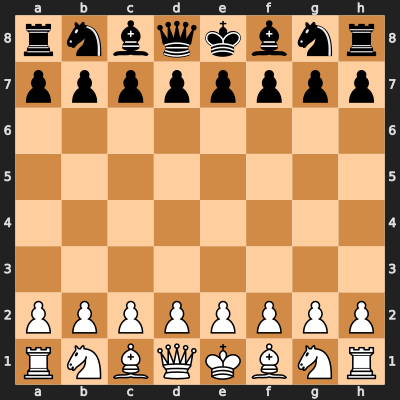

In [27]:
chess_game

In [28]:
my_play=busca_heuristica(chess_game)
print('Raciocínio:',my_play)
if chess_game.board.turn == chess.WHITE:
    print("Alg. busca com as peças brancas")
else:
    print("Alg. busca com as peças pretas")
print('Minha jogada é:',my_play[1])

Raciocínio: ['root', 'd4 (85.0)', 'd5 (85.0)', 'Qd3 (85.0)']
Alg. busca com as peças brancas
Minha jogada é: d4 (85.0)


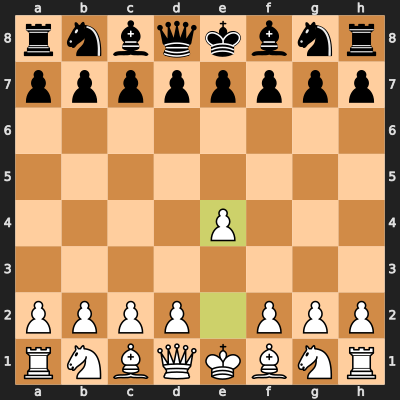

In [29]:
# Efetua a jogada do Agente e mostra tabuleiro
my_play='e4'
chess_game.push(my_play)

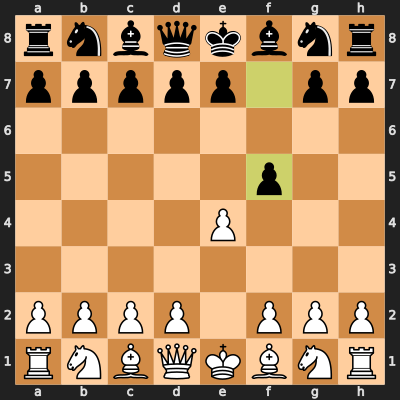

In [30]:
# Entre a jogada do adversario (humano , gen AI, etc)

op_play='f5'
chess_game.push(op_play)